In [1]:
import math 
import torch 
from torch import nn 
from d2l import torch as d2l 

batch_size, max_window_size, num_noise_words = 512, 5, 5 
data_iter, vocab = d2l.load_data_ptb(batch_size, max_window_size, num_noise_words)

跳元模型<br>
在给定中心词的情况下考虑生成周围上下文词的条件概率

嵌入层

In [2]:
embed = nn.Embedding(num_embeddings=20, embedding_dim=4)
print(f'Parameter embedding_weight ({embed.weight.shape}, dtype={embed.weight.dtype})')

Parameter embedding_weight (torch.Size([20, 4]), dtype=torch.float32)


In [3]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])       # 词元的索引
embed(x)

tensor([[[-0.9052,  1.9017,  2.3282,  0.3979],
         [-0.3105, -0.3884, -0.0952, -0.2708],
         [ 0.5310,  0.1811, -0.8279, -0.5675]],

        [[ 0.2344, -1.0988,  0.4503,  1.2869],
         [-1.8403, -0.0099, -0.3372, -0.2299],
         [ 0.0559,  0.3099, -1.7461,  1.1387]]], grad_fn=<EmbeddingBackward0>)

定义前向传播

In [4]:
def skip_gram(center, contexts_and_negatives, embed_v, embed_u):
    v = embed_v(center)
    u = embed_u(contexts_and_negatives)
    pred = torch.bmm(v, u.permute(0, 2, 1))
    return pred

In [5]:
skip_gram(torch.ones((2, 1), dtype=torch.long), 
          torch.ones((2, 4), dtype=torch.long), embed, embed).shape

torch.Size([2, 1, 4])

训练

二元交叉熵损失

In [6]:
class SigmoidBCELoss(nn.Module):
    """带掩码的二元交叉熵损失"""
    def __init__(self):
        super().__init__()
    
    def forward(self, inputs, target, mask=None):
        out = nn.functional.binary_cross_entropy_with_logits(inputs, target, weight=mask, reduction='none')
        return out.mean(dim=1)

loss = SigmoidBCELoss()

In [7]:
pred = torch.tensor([[1.1, -2.2, 3.3, -4.4]] * 2)
label = torch.tensor([[1.0, 0.0, 0.0, 0.0], [0.0, 1.0, 0.0, 0.0]])
mask = torch.tensor([[1, 1, 1, 1], [1, 1, 0, 0]])
loss(pred, label, mask) * mask.shape[1] / mask.sum(axis=1)

tensor([0.9352, 1.8462])

In [8]:
def sigmd(x):
    return -math.log(1 / (1+math.exp(-x)))

print(f'{(sigmd(1.1) + sigmd(2.2) + sigmd(-3.3) + sigmd(4.4)) / 4:.4f}')
print(f'{(sigmd(-1.1) + sigmd(-2.2)) / 2:.4f}')

0.9352
1.8462


初始化模型参数

In [ ]:
# 嵌入层的权重即对应词向量
embed_size = 100 
net = nn.Sequential(nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_size),
                    nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_size))

定义训练阶段代码

In [10]:
def train(net, data_iter, lr, num_epochs, device=d2l.try_gpu()):
    def init_weights(m):
        """初始化嵌入层权重"""
        if type(m) == nn.Embedding:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    net = net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, num_epochs])

    # 规范化的损失之和，规范化的损失数
    metric = d2l.Accumulator(2)
    for epoch in range(num_epochs):
        timer, num_batches = d2l.Timer(), len(data_iter)
        for i, batch in enumerate(data_iter):
            optimizer.zero_grad()               # 梯度清零
            center, context_negative, mask, label = [data.to(device) for data in batch]  # 获取数据

            pred = skip_gram(center, context_negative, net[0], net[1])                   # 跳元模型
            l = (loss(pred.reshape(label.shape).float(), label.float(), mask) / mask.sum(axis=1) * mask.shape[1])
            l.sum().backward()
            optimizer.step()                    # 更新梯度
            metric.add(l.sum(), l.numel())
            if (i+1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i+1) / num_batches, (metric[0] / metric[1],))
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} tokens/sec on {str(device)}')

In [11]:
def try_xpu(i=0):
    """如果存在,则返回gpu(i),否则返回cpu()"""
    if torch.xpu.device_count() >= i+1:
        return torch.device(f'xpu:{i}')
    return torch.device('cpu')

loss 0.410, 131669.2 tokens/sec on xpu:0


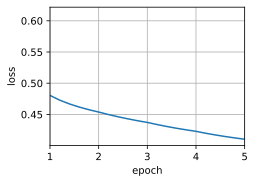

In [12]:
lr, num_epochs = 0.002, 5
train(net, data_iter, lr, num_epochs, device=try_xpu())

应用词嵌入

In [ ]:
def get_similar_tokens(query_token, k, embed):
    """找到语义最相似的k个词"""
    W = embed.weight.data
    x = W[vocab[query_token]]
    # 计算余弦相似度。增加1e-9以获得数值稳定性
    cos = torch.mv(W, x) / torch.sqrt(torch.sum(W * W, dim=1) * torch.sum(x * x) + 1e-9)
    topk = torch.topk(cos, k=k+1)[1].cpu().numpy().astype('int32')
    for i in topk[1:]:   # [1:]去掉输入词
        print(f'cosine sim={float(cos[i]):.3f}: {vocab.to_tokens(i)}')

get_similar_tokens('chip', 3, net[0])

cosine sim=0.674: microprocessor
cosine sim=0.648: intel
cosine sim=0.643: hardware
